In [1]:
import sys

sys.path.append("../")

import json
import scipy
import optuna

import numpy as np
import pandas as pd

from docplex.mp.model import Model
from qiskit.circuit import ClassicalRegister, ParameterVector, QuantumCircuit, QuantumRegister
from qiskit.primitives import BackendEstimatorV2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz
from utils import objective_scipy, ObjectiveOptuna

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simulator = AerSimulator(method="statevector", device="GPU")
estimator = BackendEstimatorV2(backend=simulator)
pm = generate_preset_pass_manager(backend=simulator, optimization_level=0)

In [3]:
assets_data = pd.read_csv(filepath_or_buffer="../datasets/sp500_assets_close_price.csv", index_col=0)

with open(file="../datasets/tickers_by_sectors.json", mode="rt") as f:
    tickers_by_sectors = json.load(f)

In [4]:
len(tickers_by_sectors.keys())

11

In [5]:
for key, value in tickers_by_sectors.items():
    print(f"{key}: {len(value)}")

Technology: 78
Consumer Cyclical: 55
Communication Services: 20
Financial Services: 65
Consumer Defensive: 36
Healthcare: 59
Energy: 21
Basic Materials: 22
Industrials: 70
Utilities: 32
Real Estate: 31


In [6]:
np.random.seed(seed=42)
assets_classes = np.random.choice(list(tickers_by_sectors.keys()), size=4)
assets_by_class = {value: list(np.random.choice(tickers_by_sectors[value], size=5)) for value in assets_classes}

In [7]:
assets_by_class

{np.str_('Energy'): [np.str_('asset_252'),
  np.str_('asset_128'),
  np.str_('asset_353'),
  np.str_('asset_234'),
  np.str_('asset_234')],
 np.str_('Financial Services'): [np.str_('asset_485'),
  np.str_('asset_194'),
  np.str_('asset_442'),
  np.str_('asset_370'),
  np.str_('asset_172')],
 np.str_('Real Estate'): [np.str_('asset_47'),
  np.str_('asset_391'),
  np.str_('asset_259'),
  np.str_('asset_113'),
  np.str_('asset_459')],
 np.str_('Basic Materials'): [np.str_('asset_256'),
  np.str_('asset_174'),
  np.str_('asset_81'),
  np.str_('asset_264'),
  np.str_('asset_81')]}

In [8]:
constraints_dict = {
    "Energy": ("eq", 3),
    "Financial Services": ("gleq", 1, 2),
    "Real Estate": ("eq", 2),
    "Basic Materials": ("leq", 4)
}

In [9]:
scipy.special.comb(5,3)*(sum([scipy.special.comb(5,i) for i in range(1,3)]))*scipy.special.comb(5,2)*(sum([scipy.special.comb(5,i) for i in range(1,5)]))

np.float64(45000.0)

In [10]:
tickers = []
for value in assets_by_class.values():
    tickers.extend(list(value))

In [11]:
assets_close_price = assets_data[tickers]

In [12]:
assets_pct_change = assets_close_price.pct_change().dropna()
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [13]:
constraints_matrix = np.zeros(shape=(len(assets_by_class.keys()), len(tickers)))

In [14]:
for idx, key in enumerate(assets_by_class.keys()):
    constraints_matrix[idx,:] = assets_close_price.columns.isin(assets_by_class[key]).astype(int)

In [15]:
constraints_matrix

array([[1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        1., 1., 1., 1.]])

In [16]:
q = 0.5
return_risk_free = 0.0375

In [17]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(assets_close_price.columns.shape[0])])
model.minimize(q*((x.T@covariance_annualized.values@x))-(1-q)*(returns_annualized.values@x)+return_risk_free)
for idx, key in enumerate(assets_by_class.keys()):
    tp = constraints_dict[key]
    if tp[0] == "eq":
        model.add_constraint(constraints_matrix[idx]@x == tp[1])
    elif tp[0] == "leq":
        model.add_constraint(constraints_matrix[idx]@x <= tp[1])
    elif tp[0] == "geq":
        model.add_constraint(constraints_matrix[idx]@x >= tp[1])
    elif tp[0] == "gleq":
        model.add_constraint(constraints_matrix[idx]@x >= tp[1])
        model.add_constraint(constraints_matrix[idx]@x <= tp[2])
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x(0);
dvar bool x(1);
dvar bool x(2);
dvar bool x(3);
dvar bool x(4);
dvar bool x(5);
dvar bool x(6);
dvar bool x(7);
dvar bool x(8);
dvar bool x(9);
dvar bool x(10);
dvar bool x(11);
dvar bool x(12);
dvar bool x(13);
dvar bool x(14);
dvar bool x(15);
dvar bool x(16);
dvar bool x(17);
dvar bool x(18);
dvar bool x(19);

minimize
 - 0.575693 x(0) - 0.098227 x(1) - 0.298700 x(2) - 0.261121 x(3)
 - 0.261121 x(4) - 0.177930 x(5) + 0.016777 x(6) + 0.044626 x(7)
 - 0.285886 x(8) - 0.120311 x(9) + 0.051459 x(10) + 0.041276 x(11)
 + 0.037360 x(12) - 0.114411 x(13) - 0.131285 x(14) - 0.295678 x(15)
 - 0.057492 x(16) - 0.004315 x(17) + 0.290309 x(18) - 0.004315 x(19) [
 0.006525 x(0)^2 + 0.003859 x(0)*x(1) + 0.007224 x(0)*x(2)
 + 0.007671 x(0)*x(3) + 0.007671 x(0)*x(4) + 0.000538 x(0)*x(5)
 - 0.000480 x(0)*x(6) - 0.000199 x(0)*x(7) - 0.000391 x(0)*x(8)
 - 0.000036 x(0

In [18]:
result = model.solve()

In [19]:
result.objective_value

-2.0779385417256275

In [20]:
result_array = np.array([result.get_value(f"x({i})") for i in range(assets_close_price.columns.shape[0])])

In [21]:
result_array

array([1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
       0., 0., 0.])

In [22]:
np.array(tickers)[result_array.astype(bool)]

array([np.str_('asset_252'), np.str_('asset_353'), np.str_('asset_234'),
       np.str_('asset_485'), np.str_('asset_370'), np.str_('asset_113'),
       np.str_('asset_459'), np.str_('asset_256'), np.str_('asset_174')],
      dtype='<U9')

In [23]:
constraints_matrix@result_array

array([3., 2., 2., 2.])

In [24]:
target = result_array.astype(int)
target = ""
for item in result_array.astype(int):
    target += str(item)
target = target[::-1]

In [25]:
target

'00011110000100101101'

In [26]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x({i})") for i in range(len(tickers))])
model.minimize(q*(x.T@covariance_annualized.values@x)-(1-q)*(returns_annualized.values@x)+return_risk_free)
quad_model = from_docplex_mp(model=model)
qubo_converter = OptimizationProblemToQubo(penalty=1e-12)
qubo = qubo_converter.convert(quad_model)
ising, offset = qubo.to_ising()

In [27]:
identity = SparsePauliOp(data="III", coeffs=[1])
ising_expanded = ising.tensor(other=identity)

In [28]:
ising_expanded.num_qubits

23

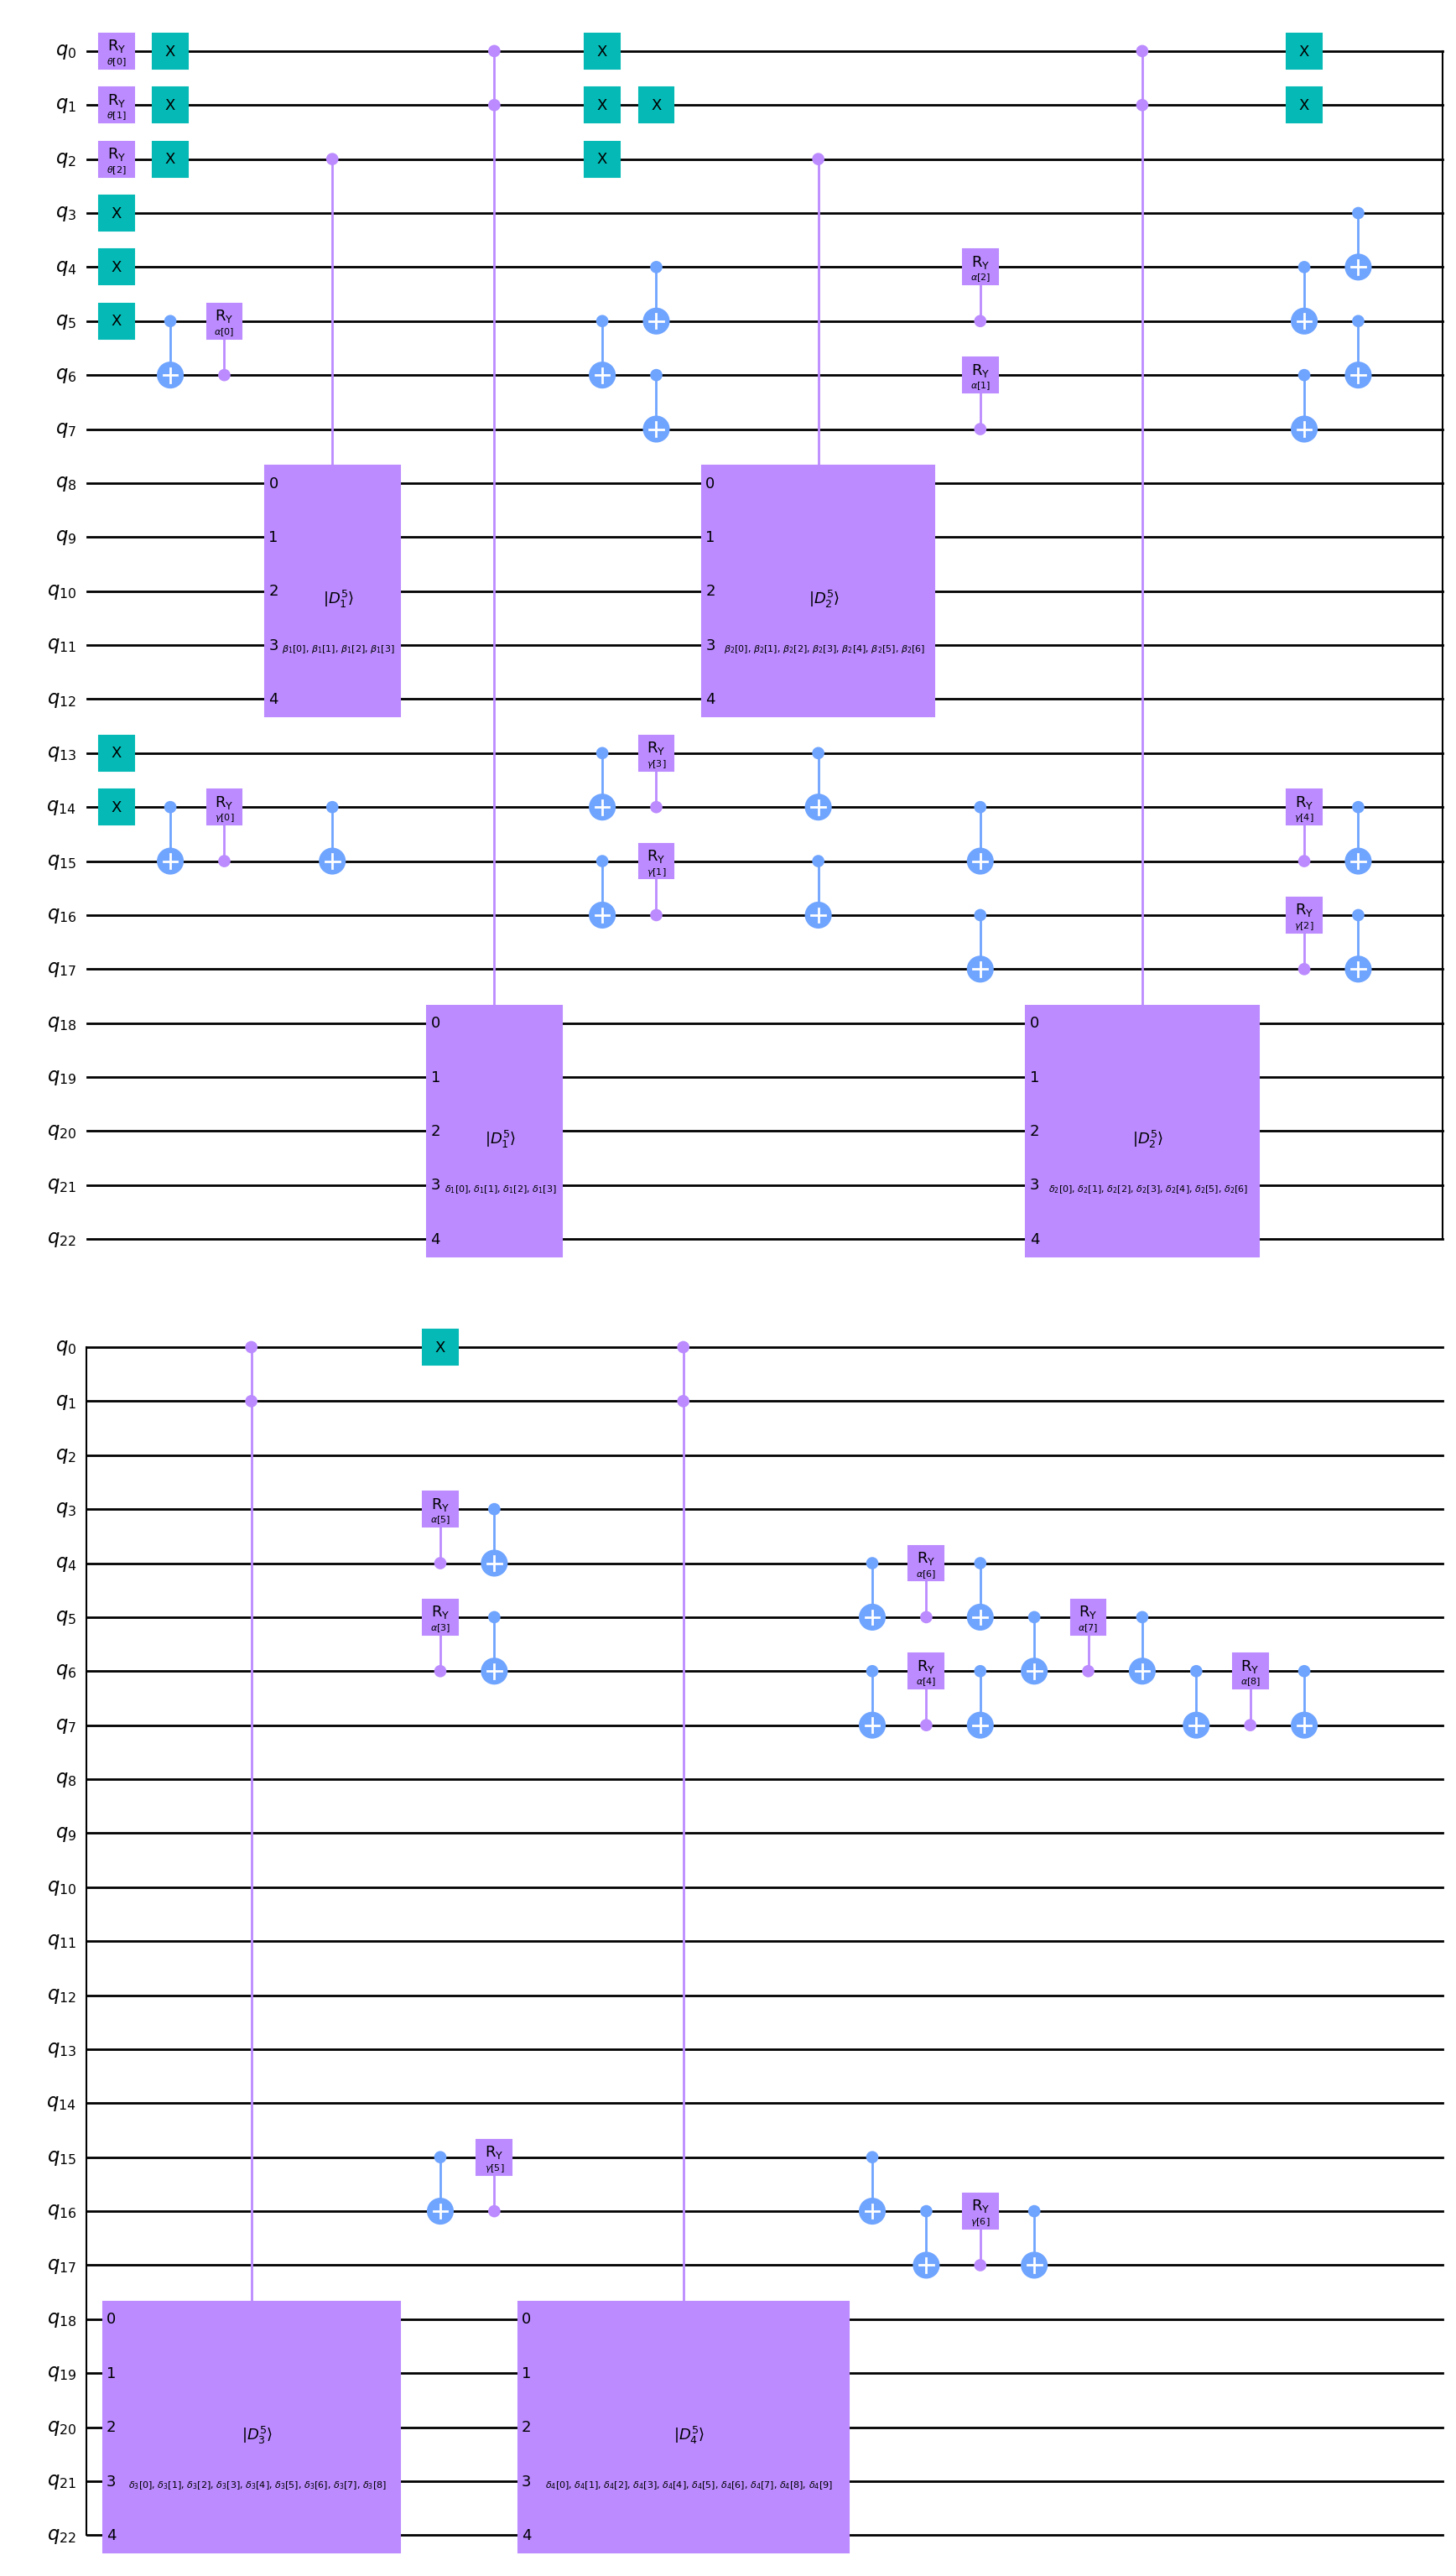

In [29]:
qubits = QuantumRegister(size=ising_expanded.num_qubits, name="q")
params_vec = ParameterVector(name=r"$\theta$", length=ising_expanded.num_qubits-ising.num_qubits)

qc = QuantumCircuit(qubits)
for idx, param in enumerate(params_vec):
    qc.ry(theta=param, qubit=qubits[idx])

qubits_dict = {
    0: [qubits[i] for i in range(3,8)],
    1: [qubits[i] for i in range(8,13)],
    2: [qubits[i] for i in range(13,18)],
    3: [qubits[i] for i in range(18,23)]
}
params_names = {0: "alpha", 1: "beta", 2: "gamma", 3: "delta"}
gate_name = {
    0: r"$\vert D^{5}_{3} \rangle$",
    1: [r"$\vert D^{5}_{1} \rangle$", r"$\vert D^{5}_{2} \rangle$"],
    2: r"$\vert D^{5}_{2} \rangle$",
    3: [r"$\vert D^{5}_{1} \rangle$", r"$\vert D^{5}_{2} \rangle$", r"$\vert D^{5}_{3} \rangle$", r"$\vert D^{5}_{4} \rangle$"],
}

for idx, key in enumerate(assets_by_class.keys()):
    tp = constraints_dict[key]
    if tp[0] == "eq":
        dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(assets_by_class[key]), k=tp[1], measurement=False, param_name=params_names[idx])
        qc = qc.compose(other=dicke, qubits=qubits_dict[idx])
    elif tp[0] == "leq":
        for k in range(1, tp[1]+1):
            dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(assets_by_class[key]), k=k, measurement=False, param_name=params_names[idx]+f"_{k}")
            if k == 1:
                qc.x(qubit=qubits[[i for i in range(2)]])
            elif k == 2:
                qc.x(qubit=qubits[1])
            elif k == 3:
                qc.x(qubit=qubits[0])
            dicke_gate = dicke.to_gate(label=gate_name[idx][k-1]).control(2)
            qc.append(dicke_gate, qargs=[qubits[0], qubits[1]]+qubits_dict[idx])
            if k == 1:
                qc.x(qubit=qubits[[i for i in range(2)]])
            elif k == 2:
                qc.x(qubit=qubits[1])
            elif k == 3:
                qc.x(qubit=qubits[0])
    elif tp[0] == "gleq":
        for k in range(tp[1], tp[2]+1):
            dicke = DickeStateAnsatz().generate_quantum_circuit(n=len(assets_by_class[key]), k=k, measurement=False, param_name=params_names[idx]+f"_{k}")
            if k == 1:
                qc.x(qubit=qubits[2])
            dicke_gate = dicke.to_gate(label=gate_name[idx][k-1]).control(1)
            qc.append(dicke_gate, qargs=[qubits[2]]+qubits_dict[idx])
            if k == 1:
                qc.x(qubit=qubits[2])

qc.draw(output="mpl", style="clifford")

In [30]:
tqc = pm.run(qc)

In [31]:
x0 = 2*np.pi*np.random.random(size=qc.num_parameters)
bounds = [(0, 2*np.pi) for _ in range(x0.shape[0])]
result = scipy.optimize.minimize(fun=objective_scipy, x0=x0, method="cobyla", bounds=bounds, args=(estimator, tqc, ising_expanded, offset))

In [32]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.765872789540475
       x: [ 4.722e-04  6.278e+00 ...  3.790e+00  6.251e+00]
    nfev: 625
   maxcv: 0.0

In [33]:
bits = ClassicalRegister(size=ising.num_qubits)
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.add_register(bits)
ansatz.measure(qubit=ansatz.qregs[0][ising_expanded.num_qubits-ising.num_qubits:], cbit=bits)

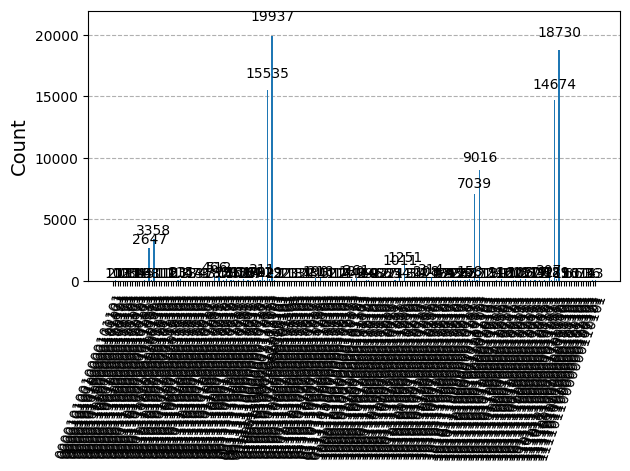

In [34]:
counts = simulator.run(circuits=ansatz, shots=100000).result().get_counts()
plot_histogram(data=counts)

In [35]:
counts[target]

KeyError: '00011110000100101101'

In [36]:
objective_optuna = ObjectiveOptuna(qc=tqc, estimator=estimator, ising=ising_expanded, offset=offset, callback=None)

In [37]:
x0_dict = {f"x[{i}]": value for i, value in enumerate(x0)}

In [38]:
sampler = optuna.samplers.CmaEsSampler(x0=x0_dict, use_separable_cma=True)
study = optuna.create_study(sampler=sampler)
study.optimize(objective_optuna, n_trials=1000)

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``use_separable_cma`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-08 22:46:06,858] A new study created in memory with name: no-name-3a91871c-b038-4a4c-bf41-2bf20402964b
[I 2026-05-08 22:46:07,033] Trial 0 finished with value: -0.9151939248955663 and parameters: {'x[0]': 3.3539612965629946, 'x[1]': 2.2511022748924128, 'x[2]': 0.994063835025863, 'x[3]': 5.709276153323147, 'x[4]': 1.5382570552469075, 'x[5]': 1.1132743700173828, 'x[6]': 1.5007050770502803, 'x[7]': 1.4761301564738107, 'x[8]': 3.9325232959758405, 'x[9]': 5.336941101920305, 'x[10]': 3.1627396119850633, 'x[11]': 4.427176739124808, 'x[12]': 0.9903368948355179, 'x[13]': 4.890060477932351, 'x[14]': 2.387650350660613, 'x[15]': 2.242524954580666, 'x[16]': 2.774498056010082, 'x[17]': 1.4517124140080402, 'x[18]': 3.074637924015495, 'x

In [39]:
study.best_value

-2.016225705325143

In [40]:
ansatz = tqc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, study.best_params.values())}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

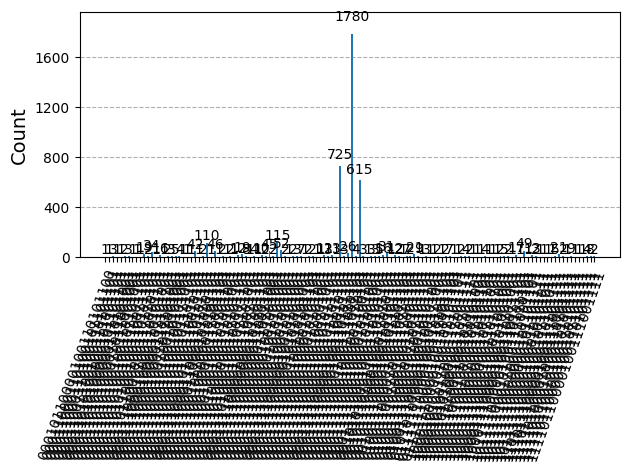

In [41]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)

In [42]:
counts[target]

KeyError: '00011110000100101101'